# 실습 20: 얼마나 빗나갔나 (회귀)
설비 고장 기록으로 공정온도를 맞혀 본다

## Step 1. 데이터 확인

In [1]:
import pandas as pd

df = pd.read_csv("../../data/16_machine-failure.csv")

print(df.shape[0], "행,", df.shape[1], "열")
print(df.columns.tolist())
df.describe().loc[["min", "max", "mean"]]

10000 행, 7 열
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
min,295.30000,305.70000,1168.0000,3.80000,0.000
max,304.50000,313.80000,2886.0000,76.60000,253.000
mean,300.00493,310.00556,1538.7761,39.98691,107.951


## Step 2. 맞힐 숫자 정하기

맞힐 것 : Process temperature [K] - 공정온도
왜 : 지금 조건에서 나와야 할 온도를 알면, 실제가 그보다 높을 때 이상 신호가 된다

### 문법 노트 - 회귀에서 새로 나오는 이름

| 쓴 것 | 하는 일 |
|---|---|
| mean_absolute_error | 평균 몇 만큼 빗나갔나 (MAE) |
| mean_squared_error | 제곱해서 평균 - 뿌리를 씌우면 RMSE |
| r2_score | 기준 모델 대비 얼마나 나은가 (R2) |
| LinearRegression | 숫자를 맞히는 모델 중 가장 단순한 것 |

## Step 3. 한 바퀴 돌리기

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

특징 = ["Air temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
X = df[특징]
y = df["Process temperature [K]"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 기준 모델: 항상 학습용 평균값
기준_예측 = np.full(len(y_test), y_train.mean())

# 선형회귀 모델
model = LinearRegression()
model.fit(X_train, y_train)
내_예측 = model.predict(X_test)

결과 = pd.DataFrame({
    "기준 모델": [
        mean_absolute_error(y_test, 기준_예측),
        mean_squared_error(y_test, 기준_예측) ** 0.5,
        r2_score(y_test, 기준_예측),
    ],
    "내 모델": [
        mean_absolute_error(y_test, 내_예측),
        mean_squared_error(y_test, 내_예측) ** 0.5,
        r2_score(y_test, 내_예측),
    ],
}, index=["MAE", "RMSE", "R2(제곱)"])

결과

,기준 모델,내 모델
MAE,1.229517,0.595020
RMSE,1.472685,0.727922
R2(제곱),-0.000003,0.755684


## Step 4. 무엇을 보고 맞혔나

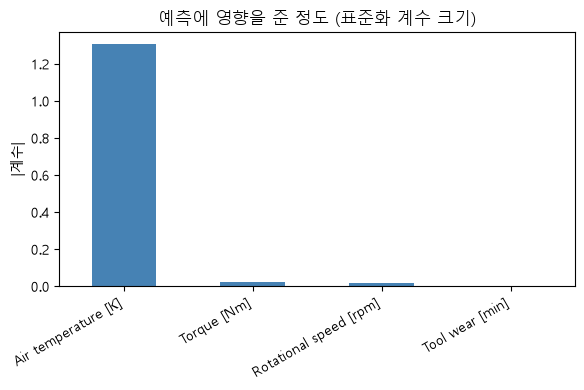

Air temperature [K]       1.304745
Torque [Nm]               0.024444
Rotational speed [rpm]    0.017912
Tool wear [min]           0.004164
dtype: float64

In [3]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 열마다 값 범위가 달라 계수를 그대로 비교할 수 없으므로 표준화 후 다시 학습
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

중요도 = pd.Series(model_scaled.coef_, index=특징).abs().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
중요도.plot(kind="bar", color="steelblue")
plt.title("예측에 영향을 준 정도 (표준화 계수 크기)")
plt.ylabel("|계수|")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

중요도

---
## 직접 해보기 (도전) - 대상을 바꾸면 자도 바뀐다

- 상황: 공정온도는 잘 맞혔는데, 다른 값도 같은 방식으로 되나
- 할 일: 맞히는 대상을 토크로 바꿔 한 번 더 돌리고 두 결과를 나란히 놓는다
- 결과물: 여섯 칸짜리 비교표 1개

In [4]:
특징_토크 = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Tool wear [min]"]
X2 = df[특징_토크]
y2 = df["Torque [Nm]"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# 기준 모델: 항상 학습용 평균값
기준_예측_토크 = np.full(len(y2_test), y2_train.mean())

# 선형회귀 모델
model_토크 = LinearRegression()
model_토크.fit(X2_train, y2_train)
내_예측_토크 = model_토크.predict(X2_test)

비교 = pd.DataFrame({
    "공정온도": [
        mean_absolute_error(y_test, 내_예측),
        mean_squared_error(y_test, 내_예측) ** 0.5,
        r2_score(y_test, 내_예측),
    ],
    "토크": [
        mean_absolute_error(y2_test, 내_예측_토크),
        mean_squared_error(y2_test, 내_예측_토크) ** 0.5,
        r2_score(y2_test, 내_예측_토크),
    ],
}, index=["MAE", "RMSE", "R2"])

비교

,공정온도,토크
MAE,0.595020,3.686211
RMSE,0.727922,4.897887
R2,0.755684,0.756591
